# 🔗 Notebook 04: Métodos Ensemble

**Proyecto:** Sistema de Detección de Phishing con Machine Learning  
**Autor:** [Tu Nombre]  
**Universidad:** [Tu Universidad]  
**Fecha:** 2024-2025

---

## Objetivos

1. ✅ Implementar **Voting Classifier** (soft voting)
2. ✅ Implementar **Stacking Classifier**
3. ✅ Comparar ensembles vs modelos individuales
4. ✅ Evaluar en test set
5. ✅ Determinar modelo final óptimo
6. ✅ Generar visualizaciones comparativas

---

## ¿Qué son los Métodos Ensemble?

Los métodos ensemble combinan múltiples modelos base para crear un modelo más robusto y preciso.

- **Voting**: Combina predicciones mediante votación (mayoría o probabilidades)
- **Stacking**: Usa un meta-modelo que aprende a combinar las predicciones de los modelos base

---

## 1. Importar Librerías

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

# Módulos propios
from ensemble_models import EnsembleManager
from evaluation import ModelEvaluator, ModelComparator, VisualizationGenerator, ReportGenerator

# Configuración
pd.set_option('display.max_columns', None)
%matplotlib inline

RANDOM_STATE = 42

print("✓ Librerías importadas exitosamente")

✓ Librerías importadas exitosamente


## 2. Cargar Datos y Modelos

In [2]:
# Cargar datos preprocesados
print("Cargando datos...")
X_train = joblib.load('../data/processed/X_train.pkl')
X_val = joblib.load('../data/processed/X_val.pkl')
X_test = joblib.load('../data/processed/X_test.pkl')
y_train = joblib.load('../data/processed/y_train.pkl')
y_val = joblib.load('../data/processed/y_val.pkl')
y_test = joblib.load('../data/processed/y_test.pkl')

print("✓ Datos cargados")
print(f"\nShapes:")
print(f"  Train: {X_train.shape}")
print(f"  Val: {X_val.shape}")
print(f"  Test: {X_test.shape}")

Cargando datos...


✓ Datos cargados

Shapes:
  Train: (188790, 40)
  Val: (35248, 40)
  Test: (35249, 40)


In [3]:
# Cargar modelos entrenados
import os
from glob import glob

model_files = glob('../models/*.pkl')
model_files = [f for f in model_files if 'scaler' not in f]  # Excluir scaler

print(f"\nCargando {len(model_files)} modelos entrenados...\n")

# Crear objetos trainer con los modelos cargados
class LoadedTrainer:
    def __init__(self, model, name):
        self.model = model
        self.model_name = name

loaded_trainers = {}
for filepath in model_files:
    model_name = os.path.basename(filepath).replace('.pkl', '')
    model = joblib.load(filepath)
    loaded_trainers[model_name] = LoadedTrainer(model, model_name)
    print(f"  ✓ {model_name}")

print(f"\n✓ {len(loaded_trainers)} modelos cargados exitosamente")


Cargando 4 modelos entrenados...

  ✓ logistic_regression
  ✓ random_forest
  ✓ svm
  ✓ xgboost

✓ 4 modelos cargados exitosamente


## 3. Crear y Entrenar Voting Classifier

In [4]:
# Inicializar manager de ensemble
ensemble_manager = EnsembleManager(random_state=RANDOM_STATE)

print("="*70)
print("            VOTING CLASSIFIER (Soft Voting)")
print("="*70)
print("\nCreando Voting Classifier...")

# Crear voting ensemble
voting_ensemble = ensemble_manager.create_voting_ensemble(
    loaded_trainers,
    voting='soft'
)

# Entrenar
print("\nEntrenando Voting Classifier...")
print("Esto puede tomar algunos minutos...\n")

voting_ensemble.train(X_train, y_train, cv=5)

print("\n✓ Voting Classifier entrenado")

2025-11-19 23:16:50,025 - ensemble_models - INFO - EnsembleManager inicializado


2025-11-19 23:16:50,025 - ensemble_models - INFO - Creando VotingEnsemble...


2025-11-19 23:16:50,025 - ensemble_models - INFO - VotingEnsemble inicializado con voting=soft


2025-11-19 23:16:50,025 - ensemble_models - INFO - Agregando estimadores desde trainers...


2025-11-19 23:16:50,025 - ensemble_models - INFO - Estimador agregado: logistic_regression


...

            VOTING CLASSIFIER (Soft Voting)

Creando Voting Classifier...

Entrenando Voting Classifier...
Esto puede tomar algunos minutos...



2025-11-19 23:17:17,932 - ensemble_models - INFO - Tiempo de entrenamiento: 27.91s


2025-11-19 23:17:17,932 - ensemble_models - INFO - Ejecutando cross-validation...


2025-11-19 23:18:26,014 - ensemble_models - INFO - CV F1-score: 1.0000 (+/- 0.0000)



✓ Voting Classifier entrenado


## 4. Crear y Entrenar Stacking Classifier

In [5]:
print("\n" + "="*70)
print("            STACKING CLASSIFIER")
print("="*70)
print("\nCreando Stacking Classifier...")

# Crear stacking ensemble (con Logistic Regression como meta-modelo)
stacking_ensemble = ensemble_manager.create_stacking_ensemble(
    loaded_trainers,
    final_estimator=None  # Usa LogisticRegression por defecto
)

# Entrenar
print("\nEntrenando Stacking Classifier...")
print("Esto puede tomar algunos minutos...\n")

stacking_ensemble.train(X_train, y_train)

print("\n✓ Stacking Classifier entrenado")

2025-11-19 23:18:26,030 - ensemble_models - INFO - Creando StackingEnsemble...


2025-11-19 23:18:26,030 - ensemble_models - INFO - StackingEnsemble inicializado


2025-11-19 23:18:26,031 - ensemble_models - INFO - Meta-modelo: LogisticRegression


2025-11-19 23:18:26,032 - ensemble_models - INFO - Agregando estimadores desde trainers...


2025-11-19 23:18:26,032 - ensemble_models - INFO - Estimador agregado: logistic_regression


...


            STACKING CLASSIFIER

Creando Stacking Classifier...

Entrenando Stacking Classifier...
Esto puede tomar algunos minutos...



2025-11-19 23:19:58,092 - ensemble_models - INFO - Tiempo de entrenamiento: 92.06s


2025-11-19 23:19:58,092 - ensemble_models - INFO - Ejecutando cross-validation...


2025-11-19 23:25:36,397 - ensemble_models - INFO - CV F1-score: 1.0000 (+/- 0.0000)



✓ Stacking Classifier entrenado


## 5. Evaluación de Ensembles en Validation Set

In [6]:
evaluator = ModelEvaluator()

# Evaluar Voting
voting_metrics_val = evaluator.evaluate_model(
    voting_ensemble.model,
    X_val,
    y_val,
    model_name="Voting Classifier"
)

# Evaluar Stacking
stacking_metrics_val = evaluator.evaluate_model(
    stacking_ensemble.model,
    X_val,
    y_val,
    model_name="Stacking Classifier"
)

print("\n" + "="*70)
print("RESULTADOS EN VALIDATION SET")
print("="*70)

print("\n🔗 Voting Classifier:")
print(f"  Accuracy:  {voting_metrics_val['accuracy']:.4f}")
print(f"  Precision: {voting_metrics_val['precision']:.4f}")
print(f"  Recall:    {voting_metrics_val['recall']:.4f}")
print(f"  F1-Score:  {voting_metrics_val['f1_score']:.4f}")
print(f"  ROC-AUC:   {voting_metrics_val['roc_auc']:.4f}")

print("\n🔗 Stacking Classifier:")
print(f"  Accuracy:  {stacking_metrics_val['accuracy']:.4f}")
print(f"  Precision: {stacking_metrics_val['precision']:.4f}")
print(f"  Recall:    {stacking_metrics_val['recall']:.4f}")
print(f"  F1-Score:  {stacking_metrics_val['f1_score']:.4f}")
print(f"  ROC-AUC:   {stacking_metrics_val['roc_auc']:.4f}")

2025-11-19 23:25:36,409 - evaluation - INFO - ModelEvaluator inicializado


2025-11-19 23:25:36,410 - evaluation - INFO - Evaluando modelo: Voting Classifier


2025-11-19 23:25:37,275 - evaluation - INFO -   Accuracy: 1.0000


2025-11-19 23:25:37,275 - evaluation - INFO -   Precision: 1.0000


2025-11-19 23:25:37,275 - evaluation - INFO -   Recall: 1.0000


...

2025-11-19 23:25:37,624 - evaluation - INFO -   Precision: 1.0000


2025-11-19 23:25:37,624 - evaluation - INFO -   Recall: 1.0000


2025-11-19 23:25:37,624 - evaluation - INFO -   F1-Score: 1.0000


2025-11-19 23:25:37,624 - evaluation - INFO -   ROC-AUC: 1.0000



RESULTADOS EN VALIDATION SET

🔗 Voting Classifier:
  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  ROC-AUC:   1.0000

🔗 Stacking Classifier:
  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  ROC-AUC:   1.0000


## 6. Comparación: Ensembles vs Modelos Individuales

In [7]:
# Cargar resultados de modelos individuales
base_results = pd.read_csv('../results/metrics/model_comparison.csv')

# Agregar ensembles
ensemble_results = pd.DataFrame([
    voting_metrics_val,
    stacking_metrics_val
])

# Combinar
all_results = pd.concat([base_results, ensemble_results], ignore_index=True)
all_results = all_results.sort_values('f1_score', ascending=False)

print("\n" + "="*70)
print("COMPARACIÓN COMPLETA: MODELOS INDIVIDUALES + ENSEMBLES")
print("="*70)
print("\n" + all_results[['model_name', 'accuracy', 'precision', 'recall', 'f1_score', 'roc_auc']].to_string(index=False))


COMPARACIÓN COMPLETA: MODELOS INDIVIDUALES + ENSEMBLES

         model_name  accuracy  precision  recall  f1_score  roc_auc
      random_forest  1.000000   1.000000     1.0  1.000000      1.0
            xgboost  1.000000   1.000000     1.0  1.000000      1.0
  Voting Classifier  1.000000   1.000000     1.0  1.000000      1.0
Stacking Classifier  1.000000   1.000000     1.0  1.000000      1.0
logistic_regression  0.999972   0.999951     1.0  0.999975      1.0
                svm  0.999972   0.999951     1.0  0.999975      1.0


### 6.1 Visualización Comparativa

✓ Visualización guardada: ../results/visualizations/final_comparison_all_models.png


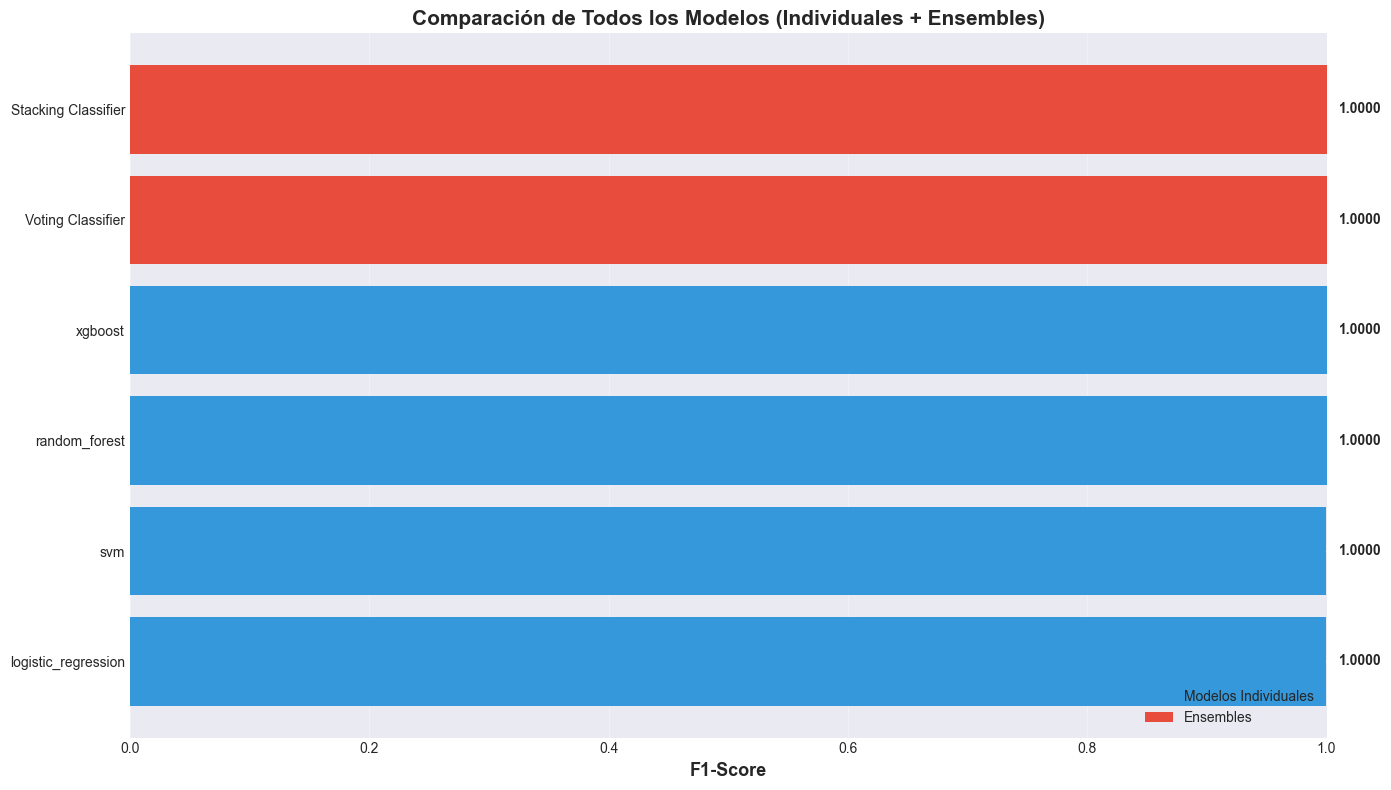

In [8]:
# Gráfico de barras comparativo
fig, ax = plt.subplots(figsize=(14, 8))

# Ordenar por F1-Score
df_sorted = all_results.sort_values('f1_score', ascending=True)

# Colores diferentes para ensembles
colors = ['#e74c3c' if 'Classifier' in name else '#3498db' 
          for name in df_sorted['model_name']]

ax.barh(df_sorted['model_name'], df_sorted['f1_score'], color=colors)
ax.set_xlabel('F1-Score', fontsize=13, fontweight='bold')
ax.set_title('Comparación de Todos los Modelos (Individuales + Ensembles)', 
             fontsize=15, fontweight='bold')
ax.set_xlim(0, 1)
ax.grid(axis='x', alpha=0.3)

# Valores
for i, v in enumerate(df_sorted['f1_score']):
    ax.text(v + 0.01, i, f'{v:.4f}', va='center', fontweight='bold')

# Leyenda
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#3498db', label='Modelos Individuales'),
    Patch(facecolor='#e74c3c', label='Ensembles')
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()

# Guardar
output_path = '../results/visualizations/final_comparison_all_models.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"✓ Visualización guardada: {output_path}")
plt.show()

## 7. Modelo Final Óptimo

In [9]:
# Determinar mejor modelo overall
best_idx = all_results['f1_score'].idxmax()
best_model_name = all_results.loc[best_idx, 'model_name']
best_f1 = all_results.loc[best_idx, 'f1_score']

print("="*70)
print("🏆 MODELO FINAL ÓPTIMO")
print("="*70)
print(f"\nModelo: {best_model_name}")
print(f"\nMétricas en Validation Set:")
print(f"  - Accuracy:  {all_results.loc[best_idx, 'accuracy']:.4f}")
print(f"  - Precision: {all_results.loc[best_idx, 'precision']:.4f}")
print(f"  - Recall:    {all_results.loc[best_idx, 'recall']:.4f}")
print(f"  - F1-Score:  {all_results.loc[best_idx, 'f1_score']:.4f}")
print(f"  - ROC-AUC:   {all_results.loc[best_idx, 'roc_auc']:.4f}")
print("\n" + "="*70)

🏆 MODELO FINAL ÓPTIMO

Modelo: random_forest

Métricas en Validation Set:
  - Accuracy:  1.0000
  - Precision: 1.0000
  - Recall:    1.0000
  - F1-Score:  1.0000
  - ROC-AUC:   1.0000



## 8. Evaluación Final en Test Set

In [10]:
# Evaluar Voting en test
voting_metrics_test = evaluator.evaluate_model(
    voting_ensemble.model,
    X_test,
    y_test,
    model_name="Voting Classifier"
)

# Evaluar Stacking en test
stacking_metrics_test = evaluator.evaluate_model(
    stacking_ensemble.model,
    X_test,
    y_test,
    model_name="Stacking Classifier"
)

print("\n" + "="*70)
print("EVALUACIÓN FINAL EN TEST SET")
print("="*70)

print("\n🔗 Voting Classifier:")
print(f"  Accuracy:  {voting_metrics_test['accuracy']:.4f}")
print(f"  Precision: {voting_metrics_test['precision']:.4f}")
print(f"  Recall:    {voting_metrics_test['recall']:.4f}")
print(f"  F1-Score:  {voting_metrics_test['f1_score']:.4f}")
print(f"  ROC-AUC:   {voting_metrics_test['roc_auc']:.4f}")

print("\n🔗 Stacking Classifier:")
print(f"  Accuracy:  {stacking_metrics_test['accuracy']:.4f}")
print(f"  Precision: {stacking_metrics_test['precision']:.4f}")
print(f"  Recall:    {stacking_metrics_test['recall']:.4f}")
print(f"  F1-Score:  {stacking_metrics_test['f1_score']:.4f}")
print(f"  ROC-AUC:   {stacking_metrics_test['roc_auc']:.4f}")

print("\n" + "="*70)

2025-11-19 23:25:38,457 - evaluation - INFO - Evaluando modelo: Voting Classifier


2025-11-19 23:25:38,950 - evaluation - INFO -   Accuracy: 1.0000


2025-11-19 23:25:38,951 - evaluation - INFO -   Precision: 1.0000


2025-11-19 23:25:38,951 - evaluation - INFO -   Recall: 1.0000


2025-11-19 23:25:38,952 - evaluation - INFO -   F1-Score: 1.0000


...

2025-11-19 23:25:39,306 - evaluation - INFO -   Precision: 1.0000


2025-11-19 23:25:39,307 - evaluation - INFO -   Recall: 1.0000


2025-11-19 23:25:39,307 - evaluation - INFO -   F1-Score: 1.0000


2025-11-19 23:25:39,308 - evaluation - INFO -   ROC-AUC: 1.0000



EVALUACIÓN FINAL EN TEST SET

🔗 Voting Classifier:
  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  ROC-AUC:   1.0000

🔗 Stacking Classifier:
  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  ROC-AUC:   1.0000



## 9. Guardar Modelos Ensemble

In [11]:
# Guardar ensembles
voting_ensemble.save_model('../models/voting_classifier.pkl')
stacking_ensemble.save_model('../models/stacking_classifier.pkl')

print("✓ Modelos ensemble guardados:")
print("  - ../models/voting_classifier.pkl")
print("  - ../models/stacking_classifier.pkl")

2025-11-19 23:25:39,411 - ensemble_models - INFO - VotingClassifier guardado en: ../models/voting_classifier.pkl


2025-11-19 23:25:39,515 - ensemble_models - INFO - StackingClassifier guardado en: ../models/stacking_classifier.pkl


✓ Modelos ensemble guardados:
  - ../models/voting_classifier.pkl
  - ../models/stacking_classifier.pkl


## 10. Generar Reporte Final

In [12]:
# Generar reporte final
report_gen = ReportGenerator(output_dir='../results/reports')

dataset_info = {
    'total_samples': len(X_train) + len(X_val) + len(X_test),
    'n_features': X_train.shape[1],
    'phishing_samples': (y_train == 1).sum() + (y_val == 1).sum() + (y_test == 1).sum(),
    'legitimate_samples': (y_train == 0).sum() + (y_val == 0).sum() + (y_test == 0).sum()
}

report_gen.generate_final_report(
    all_results,
    best_model_name,
    dataset_info,
    output_filename='final_report.md'
)

print("\n✓ Reporte final generado: ../results/reports/final_report.md")

2025-11-19 23:25:39,525 - evaluation - INFO - ReportGenerator inicializado. Output: ../results/reports


2025-11-19 23:25:39,528 - evaluation - INFO - Generando reporte final...


2025-11-19 23:25:39,545 - evaluation - INFO - Reporte final generado: ../results/reports\final_report.md



✓ Reporte final generado: ../results/reports/final_report.md


## 11. Resumen Final

In [13]:
print("="*70)
print("               RESUMEN DE ENSEMBLE METHODS")
print("="*70)

print(f"\n🔗 ENSEMBLES CREADOS:")
print(f"  ✓ Voting Classifier (soft voting)")
print(f"  ✓ Stacking Classifier (meta-modelo: Logistic Regression)")

print(f"\n📊 RESULTADOS (Test Set):")
print(f"  Voting Classifier:")
print(f"    - F1-Score: {voting_metrics_test['f1_score']:.4f}")
print(f"    - Accuracy: {voting_metrics_test['accuracy']:.4f}")
print(f"  Stacking Classifier:")
print(f"    - F1-Score: {stacking_metrics_test['f1_score']:.4f}")
print(f"    - Accuracy: {stacking_metrics_test['accuracy']:.4f}")

print(f"\n🏆 MODELO FINAL: {best_model_name}")
print(f"  - F1-Score: {best_f1:.4f}")

print(f"\n💾 ARCHIVOS GENERADOS:")
print(f"  - Modelos ensemble: ../models/")
print(f"  - Visualizaciones: ../results/visualizations/")
print(f"  - Reporte final: ../results/reports/final_report.md")

print("\n" + "="*70)
print("\n✅ ENSEMBLE METHODS COMPLETADO")
print("\n📌 Próximo paso: Notebook 05 - Validación con Datos de Perú")
print("="*70)

               RESUMEN DE ENSEMBLE METHODS

🔗 ENSEMBLES CREADOS:
  ✓ Voting Classifier (soft voting)
  ✓ Stacking Classifier (meta-modelo: Logistic Regression)

📊 RESULTADOS (Test Set):
  Voting Classifier:
    - F1-Score: 1.0000
    - Accuracy: 1.0000
  Stacking Classifier:
    - F1-Score: 1.0000
    - Accuracy: 1.0000

🏆 MODELO FINAL: random_forest
  - F1-Score: 1.0000

💾 ARCHIVOS GENERADOS:
  - Modelos ensemble: ../models/
  - Visualizaciones: ../results/visualizations/
  - Reporte final: ../results/reports/final_report.md


✅ ENSEMBLE METHODS COMPLETADO

📌 Próximo paso: Notebook 05 - Validación con Datos de Perú
